# Lot D — Analyse quantitative & qualitative
## ELOQUENT CLEF 2026 — Cultural Robustness (specific)

Ce notebook compare les runs **Groq (500q/langue)** et **Qwen local (10q/langue)** sur le dataset `specific`.

**Plan :**
1. Chargement des données
2. Statistiques simples (longueur, réponses vides, respect de la consigne)
3. Analyse sémantique (diversité & cohérence par embeddings)
4. Comparaison Groq vs Qwen
5. Analyse qualitative (exemples, typologies d'erreurs)

## 0. Installation des dépendances

In [11]:
# À lancer une seule fois
#!pip install pandas matplotlib seaborn sentence-transformers scikit-learn numpy
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.2 -> 26.1.2
[notice] To update, run: C:\Users\Paul-AlexandreBaudra\AppData\Local\Programs\Python\Python313\python.exe -m pip install --upgrade pip


## 1. Chargement des données

In [19]:
import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ── Style global ──────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

LANGUAGES = ["fr", "it", "en", "es", "de"]
DATASET_TYPE = "specific"
RUNS_DIR = Path("../data/output/runs")

In [20]:
def load_run(run_dir: Path, dataset_type: str, languages: list[str]) -> pd.DataFrame:
    """
    Charge tous les fichiers JSONL d'un run dans un DataFrame unique.
    Colonnes : id, prompt, answer, language, run_id, model, provider
    """
    # Lecture des métadonnées du run
    meta_path = run_dir / "run_metadata.json"
    meta = json.loads(meta_path.read_text(encoding="utf-8")) if meta_path.exists() else {}

    rows = []
    for lang in languages:
        output_file = run_dir / f"{lang}_{dataset_type}_output.jsonl"
        if not output_file.exists():
            print(f"  ⚠️  Fichier manquant : {output_file.name}")
            continue
        with output_file.open("r", encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                record = json.loads(line)
                record["language"]  = lang
                record["run_id"]    = meta.get("run_id", run_dir.name)
                record["model"]     = meta.get("model", "unknown")
                record["provider"]  = meta.get("provider", "unknown")
                rows.append(record)

    df = pd.DataFrame(rows)
    # Normalisation : le champ question peut s'appeler prompt, question, query
    for col in ("prompt", "question", "query", "text"):
        if col in df.columns and "prompt" not in df.columns:
            df = df.rename(columns={col: "prompt"})
            break
    if "prompt" not in df.columns:
        # Fallback : prendre la première colonne string
        str_cols = [c for c in df.columns if df[c].dtype == object and c not in ("answer", "id", "language", "run_id", "model", "provider")]
        if str_cols:
            df = df.rename(columns={str_cols[0]: "prompt"})

    print(f"  ✓ {len(df)} enregistrements chargés — modèle : {meta.get('model', '?')}")
    return df

In [21]:
# ── Détection automatique des dossiers de run ──────────────────────────────
run_dirs = sorted([d for d in RUNS_DIR.iterdir() if d.is_dir()], reverse=True)
print(f"{len(run_dirs)} run(s) trouvé(s) :")
for i, d in enumerate(run_dirs):
    meta = {}
    mp = d / "run_metadata.json"
    if mp.exists():
        meta = json.loads(mp.read_text(encoding="utf-8"))
    print(f"  [{i}] {d.name}  →  provider={meta.get('provider','?')}  model={meta.get('model','?')}  questions/langue={meta.get('max_questions','?')}")

3 run(s) trouvé(s) :
  [0] baseline_qwen_vanilla_20260416_163658  →  provider=qwen_ollama  model=qwen2.5:3b  questions/langue=10
  [1] baseline_groq_vanilla_20260415_201145  →  provider=groq  model=llama-3.1-8b-instant  questions/langue=500
  [2] baseline_groq_vanilla_20260407_162618  →  provider=?  model=?  questions/langue=?


In [22]:
# ── Sélection des runs à comparer ─────────────────────────────────────────
# Adapte les index selon ce qu'affiche la cellule précédente
IDX_GROQ = 0   # ← index du run Groq dans la liste ci-dessus
IDX_QWEN = 1   # ← index du run Qwen dans la liste ci-dessus

print("Chargement run Groq...")
df_groq = load_run(run_dirs[IDX_GROQ], DATASET_TYPE, LANGUAGES)
df_groq["run_label"] = "Groq (Llama)"

print("Chargement run Qwen...")
df_qwen = load_run(run_dirs[IDX_QWEN], DATASET_TYPE, LANGUAGES)
df_qwen["run_label"] = "Qwen (local)"

# DataFrame combiné pour les comparaisons
df_all = pd.concat([df_groq, df_qwen], ignore_index=True)
print(f"\nTotal combiné : {len(df_all)} enregistrements")

Chargement run Groq...
  ✓ 50 enregistrements chargés — modèle : qwen2.5:3b
Chargement run Qwen...
  ✓ 2500 enregistrements chargés — modèle : llama-3.1-8b-instant

Total combiné : 2550 enregistrements


## 2. Statistiques simples

In [24]:
import re

def compute_basic_stats(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcule pour chaque ligne :
      - answer_len        : longueur en caractères
      - answer_words      : nombre de mots
      - is_empty          : réponse vide ou absente
      - mentions_country  : mention explicite d'un pays
      - is_too_long       : plus de 2 phrases
    """

    df = df.copy()

    # Normalisation
    df["answer"] = df["answer"].fillna("").astype(str)

    # Longueur
    df["answer_len"] = df["answer"].str.len()
    df["answer_words"] = df["answer"].str.split().str.len()

    # Réponses vides
    df["is_empty"] = df["answer"].str.strip().eq("")

    # Détection de pays (groupe NON capturant => plus de warning)
    COUNTRY_PATTERN = (
        r"\b(?:"
        r"france|allemagne|espagne|italie|hongrie|slovénie|portugal|suède|"
        r"liechtenstein|"
        r"germany|spain|italy|hungary|slovenia|sweden|"
        r"frankreich|spanien|italien|schweden|ungarn"
        r")\b"
    )

    df["mentions_country"] = df["answer"].str.contains(
        COUNTRY_PATTERN,
        flags=re.IGNORECASE,
        regex=True,
        na=False,
    )

    # Plus de 2 phrases (proxy)
    df["is_too_long"] = df["answer"].str.count(r"[.!?]") > 2

    return df


df_groq = compute_basic_stats(df_groq)
df_qwen = compute_basic_stats(df_qwen)
df_all = pd.concat([df_groq, df_qwen], ignore_index=True)
print("Statistiques calculées ✓")

Statistiques calculées ✓


In [25]:
# ── Tableau récapitulatif global ───────────────────────────────────────────
summary = df_all.groupby("run_label").agg(
    total            = ("id",               "count"),
    vides_pct        = ("is_empty",          lambda x: f"{x.mean()*100:.1f}%"),
    moy_mots         = ("answer_words",      lambda x: f"{x.mean():.1f}"),
    median_mots      = ("answer_words",      lambda x: f"{x.median():.0f}"),
    mentionne_pays_pct = ("mentions_country", lambda x: f"{x.mean()*100:.1f}%"),
    trop_long_pct    = ("is_too_long",       lambda x: f"{x.mean()*100:.1f}%"),
).reset_index()

summary.columns = ["Modèle", "Total", "Réponses vides", "Moy. mots", "Médiane mots", "Mentionne pays", "Trop long (>2 phrases)"]
print(summary.to_string(index=False))

      Modèle  Total Réponses vides Moy. mots Médiane mots Mentionne pays Trop long (>2 phrases)
Groq (Llama)     50           0.0%      25.1           24           4.0%                   0.0%
Qwen (local)   2500           0.0%      33.2           32           0.5%                   1.4%


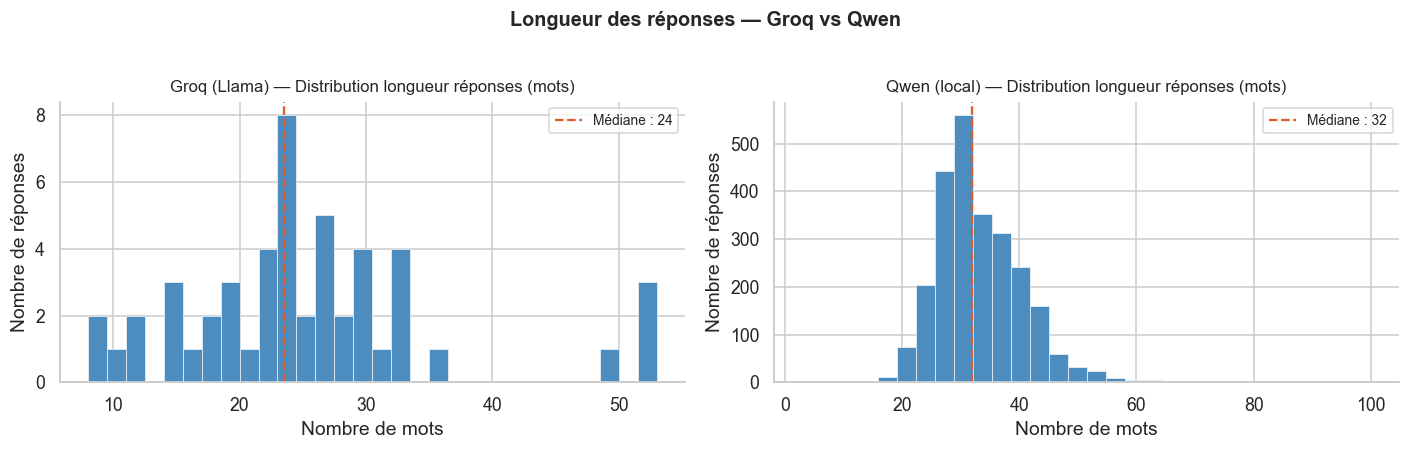

In [26]:
# ── Graphique : distribution longueur des réponses ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, (label, grp) in zip(axes, df_all.groupby("run_label")):
    grp["answer_words"].clip(upper=100).hist(
        bins=30, ax=ax, color="#4C8CBF", edgecolor="white", linewidth=0.4
    )
    ax.set_title(f"{label} — Distribution longueur réponses (mots)", fontsize=11)
    ax.set_xlabel("Nombre de mots")
    ax.set_ylabel("Nombre de réponses")
    ax.axvline(grp["answer_words"].median(), color="#E05A2B", lw=1.5, linestyle="--",
               label=f"Médiane : {grp['answer_words'].median():.0f}")
    ax.legend(fontsize=9)

plt.suptitle("Longueur des réponses — Groq vs Qwen", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

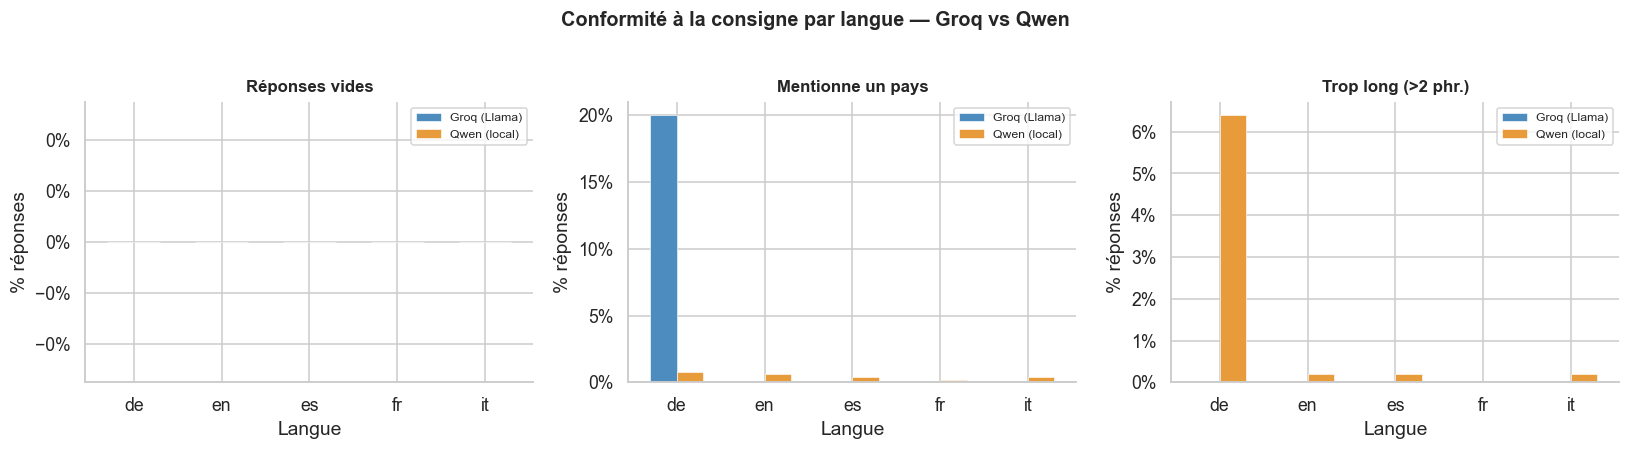

In [27]:
# ── Graphique : métriques de conformité par langue ─────────────────────────
metrics = ["is_empty", "mentions_country", "is_too_long"]
labels  = ["Réponses vides", "Mentionne un pays", "Trop long (>2 phr.)"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, metric, label in zip(axes, metrics, labels):
    pivot = df_all.groupby(["language", "run_label"])[metric].mean().unstack() * 100
    pivot.plot(kind="bar", ax=ax, width=0.6, color=["#4C8CBF", "#E89B3A"],
               edgecolor="white", linewidth=0.4)
    ax.set_title(label, fontsize=11, fontweight="bold")
    ax.set_xlabel("Langue")
    ax.set_ylabel("% réponses")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.legend(title="", fontsize=8)

plt.suptitle("Conformité à la consigne par langue — Groq vs Qwen", fontsize=13,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

## 3. Analyse sémantique — Cohérence (specific)

Pour le dataset `specific`, le pays est explicite dans chaque question.
On mesure la **cohérence** : est-ce que deux réponses à la même question de base (mais avec des pays différents) sont similaires ?

On utilise `sentence-transformers` pour calculer des embeddings, puis la **similarité cosinus** entre réponses.

In [28]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

print("Chargement du modèle d'embeddings (première fois = téléchargement ~90MB)...")
# paraphrase-multilingual-MiniLM-L12-v2 : multilingue, léger, adapté à notre cas
embedder = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
print("Modèle chargé ✓")

C:\Users\Paul-AlexandreBaudra\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Chargement du modèle d'embeddings (première fois = téléchargement ~90MB)...


C:\Users\Paul-AlexandreBaudra\AppData\Local\Programs\Python\Python313\Lib\site-packages\huggingface_hub\file_download.py:130: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Paul-AlexandreBaudra\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██

Modèle chargé ✓


In [ ]:
def compute_embeddings(df: pd.DataFrame, embedder, batch_size: int = 64) -> np.ndarray:
    """Calcule les embeddings de toutes les réponses du DataFrame."""
    answers = df["answer"].fillna("").tolist()
    embeddings = embedder.encode(
        answers,
        batch_size=batch_size,
        show_progress_bar=True,
        convert_to_numpy=True,
    )
    return embeddings

print("Calcul embeddings Groq...")
emb_groq = compute_embeddings(df_groq, embedder)

print("Calcul embeddings Qwen...")
emb_qwen = compute_embeddings(df_qwen, embedder)

df_groq["emb_idx"] = range(len(df_groq))
df_qwen["emb_idx"] = range(len(df_qwen))
print("Embeddings calculés ✓")

In [ ]:
def extract_base_question_id(record_id: str) -> str:
    """
    Extrait l'identifiant de base de la question depuis l'id ELOQUENT.
    Ex : '22-13' → '22'  (même question posée dans différents contextes pays)
    """
    return record_id.split("-")[0] if "-" in str(record_id) else str(record_id)

def cohesion_score_per_question(df: pd.DataFrame, embeddings: np.ndarray) -> pd.DataFrame:
    """
    Pour chaque question de base (même ID racine, langues différentes),
    calcule la similarité cosinus moyenne entre toutes les paires de réponses.
    Un score élevé = réponses cohérentes quelle que soit la langue → bon score robustesse.
    """
    df = df.copy()
    df["base_id"] = df["id"].astype(str).apply(extract_base_question_id)

    results = []
    for base_id, group in df.groupby("base_id"):
        if len(group) < 2:
            continue  # besoin d'au moins 2 langues pour comparer
        idxs = group["emb_idx"].tolist()
        embs = embeddings[idxs]
        sim_matrix = cosine_similarity(embs)
        # Moyenne des similarités hors diagonale
        n = len(embs)
        off_diag = (sim_matrix.sum() - np.trace(sim_matrix)) / (n * (n - 1))
        results.append({
            "base_id":       base_id,
            "n_languages":   len(group),
            "cohesion_score": round(off_diag, 4),
            "languages":     sorted(group["language"].tolist()),
        })

    return pd.DataFrame(results).sort_values("cohesion_score")

print("Calcul scores de cohésion Groq...")
cohesion_groq = cohesion_score_per_question(df_groq, emb_groq)

print("Calcul scores de cohésion Qwen...")
cohesion_qwen = cohesion_score_per_question(df_qwen, emb_qwen)

print(f"\nGroq  — cohésion moyenne : {cohesion_groq['cohesion_score'].mean():.3f}")
print(f"Qwen  — cohésion moyenne : {cohesion_qwen['cohesion_score'].mean():.3f}")

In [ ]:
# ── Graphique : distribution des scores de cohésion ───────────────────────
fig, ax = plt.subplots(figsize=(10, 4))

ax.hist(cohesion_groq["cohesion_score"], bins=30, alpha=0.65,
        color="#4C8CBF", label=f"Groq — moy. {cohesion_groq['cohesion_score'].mean():.3f}",
        edgecolor="white", linewidth=0.4)
ax.hist(cohesion_qwen["cohesion_score"], bins=30, alpha=0.65,
        color="#E89B3A", label=f"Qwen — moy. {cohesion_qwen['cohesion_score'].mean():.3f}",
        edgecolor="white", linewidth=0.4)

ax.axvline(cohesion_groq["cohesion_score"].mean(), color="#2a5e8a", lw=1.5, linestyle="--")
ax.axvline(cohesion_qwen["cohesion_score"].mean(), color="#9e5f00", lw=1.5, linestyle="--")

ax.set_xlabel("Score de cohésion (similarité cosinus inter-langues)")
ax.set_ylabel("Nombre de questions")
ax.set_title("Cohérence culturelle (specific) — Groq vs Qwen\n"
             "Score élevé = réponses similaires entre langues pour la même question",
             fontsize=11, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ── Score de cohésion par langue ───────────────────────────────────────────
def cohesion_by_language(df: pd.DataFrame, embeddings: np.ndarray) -> pd.DataFrame:
    """Calcule la cohésion moyenne pour chaque paire de langues."""
    df = df.copy()
    df["base_id"] = df["id"].astype(str).apply(extract_base_question_id)
    df["embedding"] = list(embeddings)

    results = []
    for lang in LANGUAGES:
        lang_df = df[df["language"] == lang]
        other_df = df[df["language"] != lang]
        common = set(lang_df["base_id"]) & set(other_df["base_id"])
        if not common:
            continue
        sims = []
        for base_id in common:
            e1 = lang_df[lang_df["base_id"] == base_id]["embedding"].values
            e2 = other_df[other_df["base_id"] == base_id]["embedding"].values
            if len(e1) == 0 or len(e2) == 0:
                continue
            v1 = np.stack(e1)
            v2 = np.stack(e2)
            sims.append(cosine_similarity(v1, v2).mean())
        results.append({"language": lang, "cohesion_vs_others": np.mean(sims)})

    return pd.DataFrame(results)

cbl_groq = cohesion_by_language(df_groq, emb_groq)
cbl_qwen = cohesion_by_language(df_qwen, emb_qwen)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(LANGUAGES))
w = 0.35

groq_vals = [cbl_groq[cbl_groq["language"]==l]["cohesion_vs_others"].values[0]
             if l in cbl_groq["language"].values else 0 for l in LANGUAGES]
qwen_vals = [cbl_qwen[cbl_qwen["language"]==l]["cohesion_vs_others"].values[0]
             if l in cbl_qwen["language"].values else 0 for l in LANGUAGES]

ax.bar(x - w/2, groq_vals, w, label="Groq",  color="#4C8CBF", edgecolor="white")
ax.bar(x + w/2, qwen_vals, w, label="Qwen",  color="#E89B3A", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels([l.upper() for l in LANGUAGES])
ax.set_ylabel("Cohésion moyenne vs autres langues")
ax.set_title("Cohésion par langue (specific) — Groq vs Qwen", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. Comparaison structurée Groq vs Qwen

In [ ]:
# ── Tableau de comparaison par langue ─────────────────────────────────────
rows = []
for lang in LANGUAGES:
    g = df_groq[df_groq["language"] == lang]
    q = df_qwen[df_qwen["language"] == lang]
    rows.append({
        "Langue":           lang.upper(),
        "Groq — moy. mots": f"{g['answer_words'].mean():.1f}",
        "Qwen — moy. mots": f"{q['answer_words'].mean():.1f}",
        "Groq — vides %":   f"{g['is_empty'].mean()*100:.1f}%",
        "Qwen — vides %":   f"{q['is_empty'].mean()*100:.1f}%",
        "Groq — pays %":    f"{g['mentions_country'].mean()*100:.1f}%",
        "Qwen — pays %":    f"{q['mentions_country'].mean()*100:.1f}%",
    })

comp_df = pd.DataFrame(rows)
print(comp_df.to_string(index=False))

## 5. Analyse qualitative

On sélectionne des exemples représentatifs pour chaque catégorie d'erreur ou d'écart.

In [ ]:
def display_examples(df: pd.DataFrame, mask: pd.Series, label: str, n: int = 3) -> None:
    """Affiche n exemples correspondant au masque, de façon lisible."""
    subset = df[mask].head(n)
    if subset.empty:
        print(f"\n── {label} : aucun exemple trouvé ──")
        return
    print(f"\n{'='*70}")
    print(f"  {label} ({len(df[mask])} cas au total, {n} affichés)")
    print(f"{'='*70}")
    for _, row in subset.iterrows():
        prompt_display = row.get("prompt", "")[:120] + "..." if len(str(row.get("prompt",""))) > 120 else row.get("prompt","")
        print(f"  ID       : {row['id']}")
        print(f"  Langue   : {row['language'].upper()}")
        print(f"  Prompt   : {prompt_display}")
        print(f"  Réponse  : {row['answer']}")
        print(f"  {'-'*60}")

In [ ]:
# ── Catégorie 1 : Réponses vides ──────────────────────────────────────────
display_examples(df_groq, df_groq["is_empty"], "[GROQ] Réponses VIDES")
display_examples(df_qwen, df_qwen["is_empty"], "[QWEN] Réponses VIDES")

In [ ]:
# ── Catégorie 2 : Non-respect de la consigne (mention du pays) ────────────
display_examples(df_groq, df_groq["mentions_country"], "[GROQ] Mentionne un PAYS (non-respect consigne)", n=5)
display_examples(df_qwen, df_qwen["mentions_country"], "[QWEN] Mentionne un PAYS (non-respect consigne)", n=5)

In [ ]:
# ── Catégorie 3 : Réponses très longues (non-respect consigne 1 phrase) ───
display_examples(df_groq, df_groq["is_too_long"], "[GROQ] Réponses TROP LONGUES (>2 phrases)", n=3)
display_examples(df_qwen, df_qwen["is_too_long"], "[QWEN] Réponses TROP LONGUES (>2 phrases)", n=3)

In [ ]:
# ── Catégorie 4 : Questions les MOINS cohérentes (hallucinations culturelles)
# Questions où les réponses varient le plus entre langues pour Groq
print("\n=== GROQ — Questions les MOINS cohérentes (top 5) ===")
worst_groq = cohesion_groq.head(5)
for _, row in worst_groq.iterrows():
    print(f"\n  Base ID : {row['base_id']} | Score cohésion : {row['cohesion_score']} | Langues : {row['languages']}")
    examples = df_groq[df_groq["id"].astype(str).apply(extract_base_question_id) == row["base_id"]]
    for _, ex in examples.iterrows():
        print(f"    [{ex['language'].upper()}] {ex['answer'][:120]}")

In [ ]:
# ── Catégorie 5 : Questions les PLUS cohérentes (bonnes pratiques) ─────────
print("\n=== GROQ — Questions les PLUS cohérentes (top 5) ===")
best_groq = cohesion_groq.tail(5)
for _, row in best_groq.iterrows():
    print(f"\n  Base ID : {row['base_id']} | Score cohésion : {row['cohesion_score']} | Langues : {row['languages']}")
    examples = df_groq[df_groq["id"].astype(str).apply(extract_base_question_id) == row["base_id"]]
    for _, ex in examples.iterrows():
        print(f"    [{ex['language'].upper()}] {ex['answer'][:120]}")

In [ ]:
# ── Catégorie 6 : Réponses génériques (peu de contenu informatif) ──────────
GENERIC_PATTERNS = [
    r"\bcela dépend\b", r"\bil est important\b", r"\ben général\b",
    r"\bit depends\b",  r"\bin general\b",       r"\bdepende\b",
    r"\bes importante\b", r"\bim allgemeinen\b",  r"\bdipende\b",
]
generic_pattern = "|".join(GENERIC_PATTERNS)
df_groq["is_generic"] = df_groq["answer"].str.lower().str.contains(generic_pattern, regex=True, na=False)
df_qwen["is_generic"] = df_qwen["answer"].str.lower().str.contains(generic_pattern, regex=True, na=False)

print(f"Groq — réponses génériques : {df_groq['is_generic'].mean()*100:.1f}%")
print(f"Qwen — réponses génériques : {df_qwen['is_generic'].mean()*100:.1f}%")

display_examples(df_groq, df_groq["is_generic"], "[GROQ] Réponses GÉNÉRIQUES", n=3)
display_examples(df_qwen, df_qwen["is_generic"], "[QWEN] Réponses GÉNÉRIQUES", n=3)

## 6. Synthèse — Typologie des erreurs

| Catégorie | Description | Exemple type |
|---|---|---|
| **Réponse vide** | Le modèle n'a rien généré | Timeout, quota dépassé |
| **Non-respect consigne pays** | Le modèle mentionne explicitement le pays malgré l'instruction | "En France, il est courant de..." |
| **Réponse trop longue** | Plus de 2 phrases — non conforme au protocole ELOQUENT | Paragraphe au lieu d'une phrase |
| **Généricité** | Réponse passe-partout sans ancrage culturel | "Cela dépend des situations" |
| **Incohérence inter-langues** | Même question, pays différents, réponses contradictoires | Score cohésion < 0.5 |
| **Hallucination culturelle** | Affirmation fausse ou stéréotypée sur une culture | À identifier manuellement |

In [ ]:
# ── Graphique radar — Profil d'erreurs global ─────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

categories = ["Vides", "Mentionne\npays", "Trop\nlong", "Générique"]
groq_rates = [
    df_groq["is_empty"].mean() * 100,
    df_groq["mentions_country"].mean() * 100,
    df_groq["is_too_long"].mean() * 100,
    df_groq["is_generic"].mean() * 100,
]
qwen_rates = [
    df_qwen["is_empty"].mean() * 100,
    df_qwen["mentions_country"].mean() * 100,
    df_qwen["is_too_long"].mean() * 100,
    df_qwen["is_generic"].mean() * 100,
]

x = np.arange(len(categories))
w = 0.35
fig, ax = plt.subplots(figsize=(10, 4))
bars1 = ax.bar(x - w/2, groq_rates, w, label="Groq (Llama)", color="#4C8CBF", edgecolor="white")
bars2 = ax.bar(x + w/2, qwen_rates, w, label="Qwen (local)", color="#E89B3A", edgecolor="white")

ax.bar_label(bars1, fmt="%.1f%%", fontsize=8, padding=2)
ax.bar_label(bars2, fmt="%.1f%%", fontsize=8, padding=2)
ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=10)
ax.set_ylabel("% réponses concernées")
ax.set_title("Profil d'erreurs global — Groq vs Qwen", fontweight="bold")
ax.legend()
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.tight_layout()
plt.show()

print("\n── Analyse terminée ✓ ──")
print("Exporte les graphiques avec plt.savefig('nom.png', dpi=150, bbox_inches='tight')")